In [ ]:
import pandas as pd
from notebooks.consts import ORIGINAL_OLIGO_CSV

# Load the processed data
df = pd.read_csv(ORIGINAL_OLIGO_CSV)
len(df)

In [ ]:
import pandas as pd
from notebooks.consts import PROCESSED_OLIGO_CSV_GZ
from tauso.data.consts import CANONICAL_GENE

# Load the processed data
df = pd.read_csv(PROCESSED_OLIGO_CSV_GZ)

# Calculate the counts
zero_hits = df[CANONICAL_GENE].isna().sum()
multiple_hits = df[CANONICAL_GENE].dropna().astype(str).str.contains(';').sum()

total_not_unique = zero_hits + multiple_hits

# Display the results
print(f"Data length: {len(df)}")
print(f"Entries with zero hits (NA): {zero_hits}")
print(f"Entries with multiple hits (ambiguous): {multiple_hits}")
print(f"Total entries not uniquely found: {total_not_unique}")

In [1]:
from notebooks.features.feature_extraction import load_all_features

features = load_all_features(filenames=['sense_start.csv'], version='oligo')
import pandas as pd

from notebooks.consts import OLIGO_CSV_INDEXED

unprocessed_data = pd.read_csv(OLIGO_CSV_INDEXED)

In [2]:
import pandas as pd

# Subset the features DataFrame to only include the merge key and the column you want
merged_df = pd.merge(
    features[['index_oligo', 'sense_start']],
    unprocessed_data,
    on='index_oligo'
)

In [3]:
from notebooks.preprocessing import process_oligo_data

data = process_oligo_data(merged_df)

------------------------------------------------------------
PROCESSING FILTERING REPORT
------------------------------------------------------------
Initial raw rows loaded: 158,725

[0. BASE FILTERING]
Unsupported chemistry (Mixmers/DNA/None): 20,040
Steric blocking (True) eliminated: 0
Multiple genes (';' present) eliminated: 0
Missing inhibition (NaN) eliminated: 0
Missing cell line (NaN) eliminated: 4,159

[1. UNMAPPED SEQUENCES (sense_start == -1)]
Samples eliminated: 752

[2. COHORT FILTERING (>= 1 samples)]
Cohorts: 254 -> 254 (0 eliminated)
Samples: 133,774 -> 133,774 (0 eliminated)

[3. SPARSE CELL LINE FILTERING (>= 1 samples)]
Cell Lines: 29 -> 29 (0 eliminated)
Samples: 133,774 -> 133,774 (0 eliminated)

FINAL DATASET: 133,774 ASOs

ELIMINATED GROUPS BREAKDOWN

[ELIMINATED UNMAPPED SAMPLES] - 752 samples across 10 genes:
  • KCNQ2: 460 samples
  • IGF2-AS: 69 samples
  • RP11-739B23.1: 59 samples
  • MIR6801: 54 samples
  • RP11-823E8.3: 52 samples
  • F12: 21 samples
  • 

In [4]:
data['Modification']

0         MOE/5-methylcytosines/deoxy
1         MOE/5-methylcytosines/deoxy
2         MOE/5-methylcytosines/deoxy
3         MOE/5-methylcytosines/deoxy
4         MOE/5-methylcytosines/deoxy
                     ...             
158720    MOE/5-methylcytosines/deoxy
158721    MOE/5-methylcytosines/deoxy
158722    MOE/5-methylcytosines/deoxy
158723    MOE/5-methylcytosines/deoxy
158724    MOE/5-methylcytosines/deoxy
Name: Modification, Length: 133774, dtype: object

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set global aesthetics for presentation slides
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 18, 'axes.labelsize': 16})

def plot_inhibition(df, save_path="slide_inhibition.png"):
    plt.figure(figsize=(10, 6))
    inhibition_data = df['Inhibition(%)'].dropna()

    sns.histplot(inhibition_data, bins=50, kde=False, color='#4C72B0', edgecolor='black')

    plt.title('Distribution of ASO Inhibition', fontweight='bold', pad=15)
    plt.xlabel('Inhibition (%)')
    plt.ylabel('Frequency (Count)')
    sns.despine()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_cell_line_pie(df, top_n=10, save_path="slide_cell_lines.png"):
    plt.figure(figsize=(8, 8))

    counts = df['Cell_line'].value_counts()
    top_counts = counts.nlargest(top_n)
    other_count = counts.iloc[top_n:].sum()

    # Add 'Other' slice to represent the rest of the dataset
    if other_count > 0:
        top_counts['Other'] = other_count

    colors = sns.color_palette("pastel")[0:len(top_counts)]

    plt.pie(top_counts.values, labels=top_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

    plt.title(f'Top {top_n} Cell Lines Used\n', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_gene_pie_by_cell_line(df, top_n=30, save_path="slide_genes.png"):
    plt.figure(figsize=(10, 10))

    top_genes_series = df['Canonical Gene Name'].value_counts().nlargest(top_n)
    total_genes = len(df['Canonical Gene Name'].dropna())
    other_count = total_genes - top_genes_series.sum()

    # Extract dominant cell line for each top gene
    gene_data = []
    for gene, count in top_genes_series.items():
        dominant_cell = df[df['Canonical Gene Name'] == gene]['Cell_line'].mode()[0]
        gene_data.append({'gene': gene, 'count': count, 'cell_line': dominant_cell})

    # Add 'Other' category for all remaining genes
    if other_count > 0:
        gene_data.append({'gene': 'Other Genes', 'count': other_count, 'cell_line': 'Mixed'})

    df_genes = pd.DataFrame(gene_data)

    # Sort so 'Other' goes to the end, and the rest are grouped by cell line
    df_genes['is_other'] = df_genes['gene'] == 'Other Genes'
    df_genes = df_genes.sort_values(by=['is_other', 'cell_line', 'count'], ascending=[True, True, False])

    # Map each unique cell line to a color (excluding 'Mixed' which gets Grey)
    unique_cells = [c for c in df_genes['cell_line'].unique() if c != 'Mixed']
    palette = sns.color_palette("Set2", len(unique_cells))
    cell_to_color = dict(zip(unique_cells, palette))
    cell_to_color['Mixed'] = '#D3D3D3' # Light grey for 'Other'

    # Build final plotting lists
    labels = []
    for _, row in df_genes.iterrows():
        if row['gene'] == 'Other Genes':
            labels.append(row['gene'])
        else:
            labels.append(f"{row['gene']} ({row['cell_line']})")

    values = df_genes['count'].values
    colors = [cell_to_color[row['cell_line']] for _, row in df_genes.iterrows()]

    plt.pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

    plt.title(f'Top {top_n} Targeted Genes\n(Grouped by matching primary cell line)',
              fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_modifications(df, save_path="slide_modifications.png"):
    plt.figure(figsize=(8, 8))

    def simplify_chem(name):
        name = str(name).lower()
        if 'moe' in name: return 'MOE'
        if 'cet' in name: return 'cEt'
        return 'Other/Unknown'

    # Get counts for all categories including 'Other'
    chem_counts = df['Modification'].apply(simplify_chem).value_counts()

    # Define specific colors so they stay consistent regardless of order
    color_map = {
        'MOE': '#55A868',          # Green
        'cEt': '#C44E52',          # Red
        'Other/Unknown': '#D3D3D3' # Light Grey
    }
    colors = [color_map.get(idx, '#D3D3D3') for idx in chem_counts.index]

    plt.pie(chem_counts.values, labels=chem_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

    centre_circle = plt.Circle((0,0), 0.50, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('ASO Backbone Modifications', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_transfection(df, save_path="slide_transfection.png"):
    plt.figure(figsize=(10, 5))
    total_rows = len(df)

    trans_counts = df['transfection_method'].fillna('Unknown').value_counts()

    ax = sns.barplot(x=trans_counts.values, y=trans_counts.index, palette="deep")

    # Add exact numbers and global % to the end of the bars
    for i, v in enumerate(trans_counts.values):
        global_pct = (v / total_rows) * 100
        label_text = f"{v:,} ({global_pct:.1f}%)"
        ax.text(v + (max(trans_counts.values)*0.01), i, label_text,
                va='center', fontsize=14, fontweight='bold', color='#333333')

    plt.title('Transfection Methods', fontweight='bold', pad=15)
    plt.xlabel('Number of ASOs')
    plt.ylabel('')

    sns.despine(left=True, bottom=True)
    ax.set_xticks([])

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def generate_all_slide_plots(df):
    plot_inhibition(df)
    plot_cell_line_pie(df)
    plot_gene_pie_by_cell_line(df)
    plot_modifications(df)
    plot_transfection(df)
    print("All slide visuals generated!")

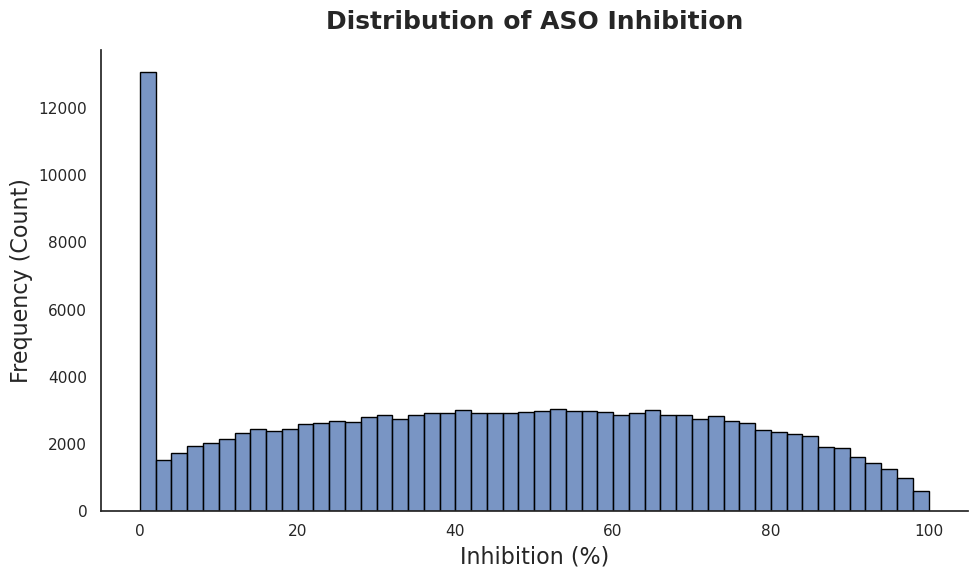

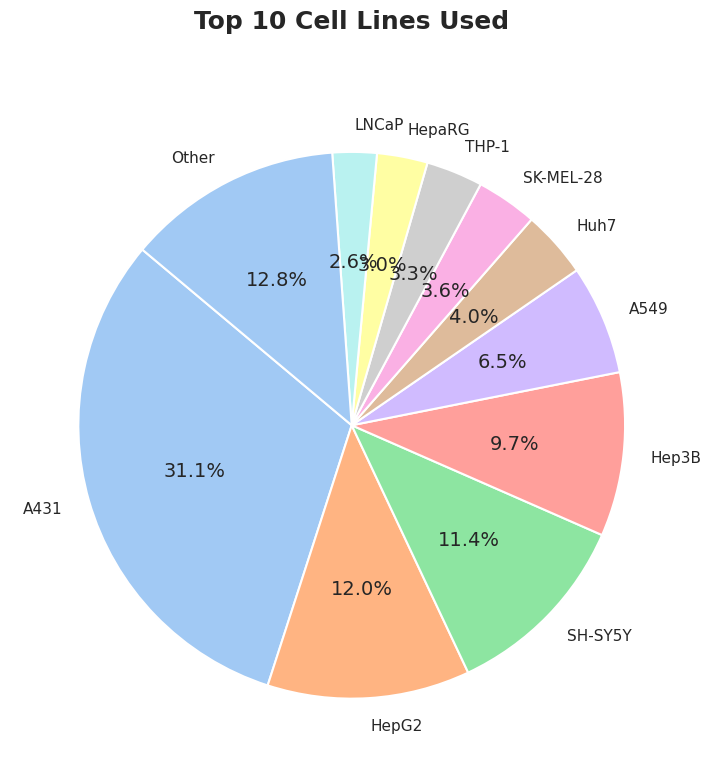

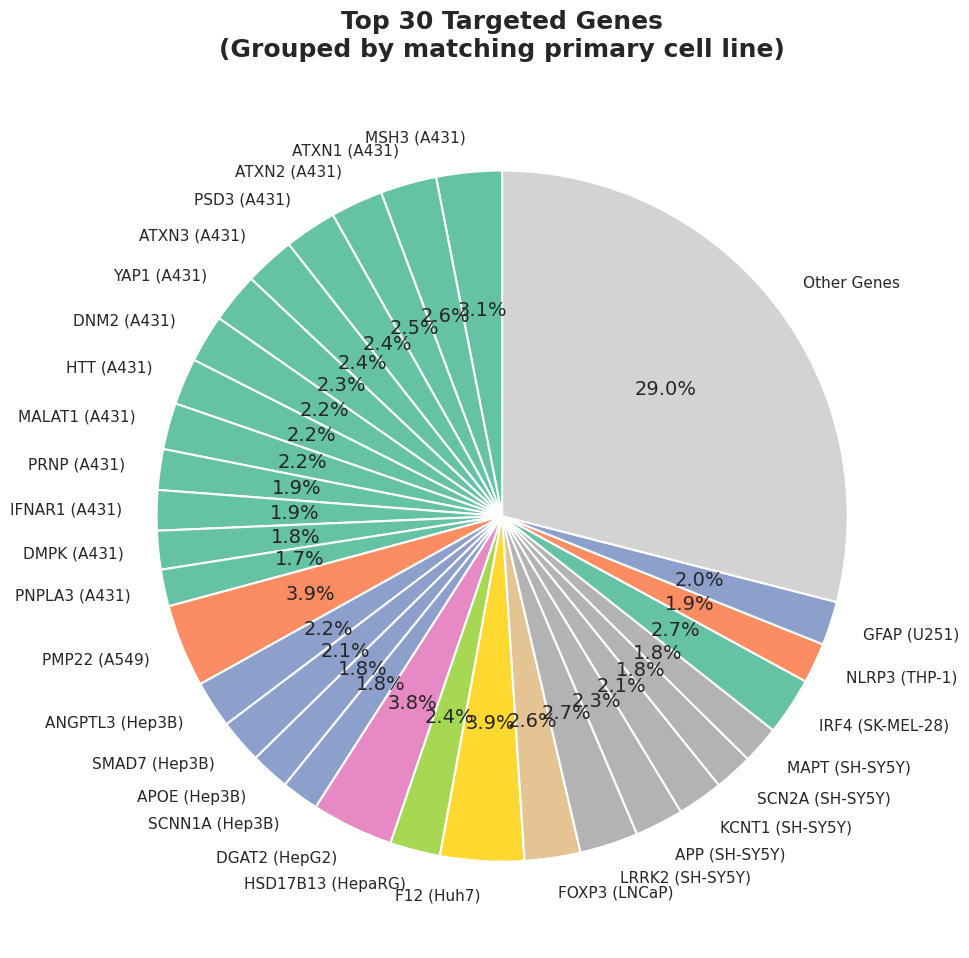

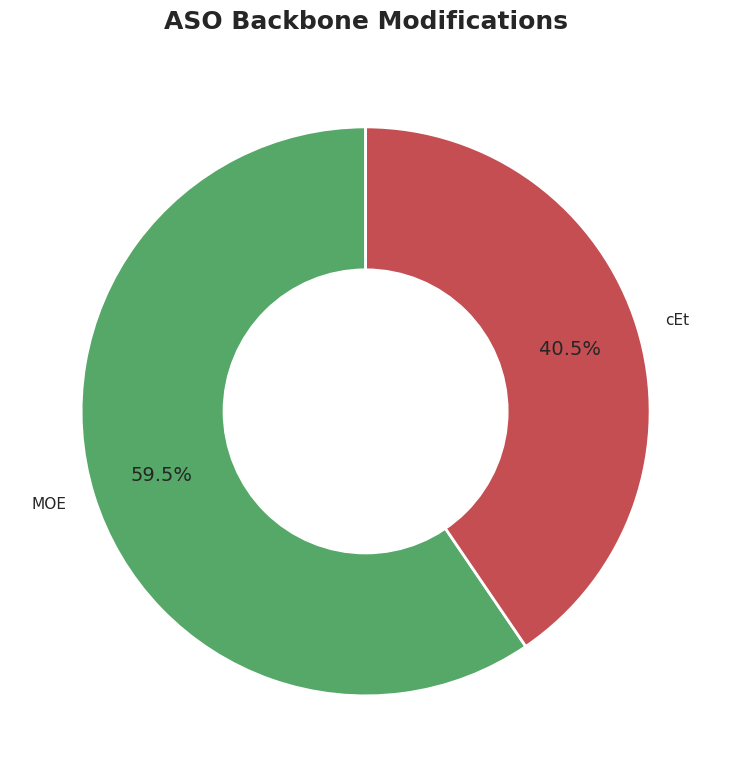

/tmp/ipykernel_97360/1515616755.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=trans_counts.values, y=trans_counts.index, palette="deep")


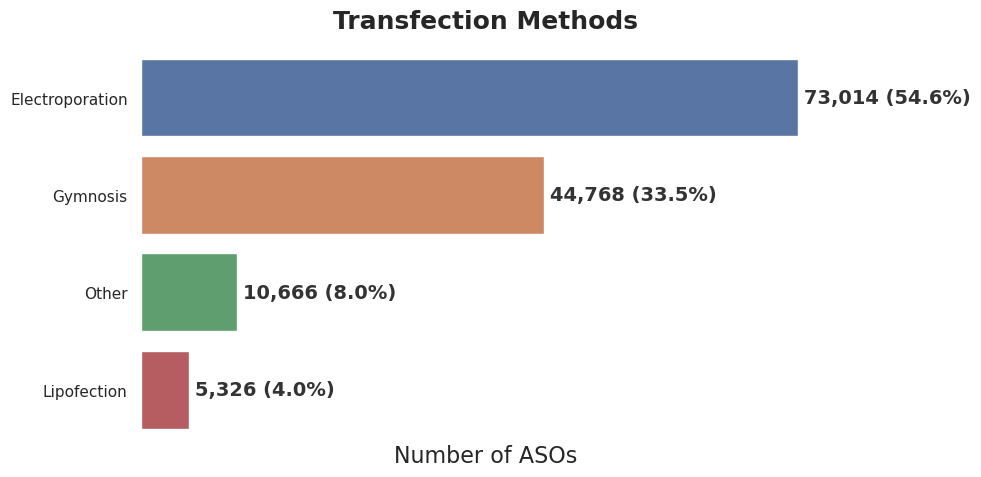

All slide visuals generated!


In [20]:
generate_all_slide_plots(data)

In [21]:
def plot_sequence_repetitions(df, save_path="slide_seq_repetitions.png"):
    plt.figure(figsize=(10, 6))

    # Calculate how many times each sequence appears
    seq_freq = df['Sequence'].value_counts()
    total_unique = len(seq_freq)

    # Group the frequencies to keep the X-axis clean
    bins = [0, 1, 2, 3, 4, 5, float('inf')]
    labels = ['1', '2', '3', '4', '5', '6+']
    binned_freq = pd.cut(seq_freq, bins=bins, labels=labels, right=True)

    rep_counts = binned_freq.value_counts().reindex(labels)

    ax = sns.barplot(x=rep_counts.index, y=rep_counts.values, palette="Blues_d")

    # Add exact counts and percentages above the bars
    for i, v in enumerate(rep_counts.values):
        if v > 0: # Only annotate if the bar exists
            pct = (v / total_unique) * 100
            ax.text(i, v + (max(rep_counts.values)*0.02), f"{v:,}\n({pct:.1f}%)",
                    ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

    plt.title(f'ASO Sequence Repetitions\n(Total Unique Sequences: {total_unique:,})',
              fontweight='bold', pad=20)
    plt.xlabel('Number of Times a Sequence Appears in Dataset')
    plt.ylabel('Number of Unique Sequences')
    sns.despine()

    # Expand upper Y limit slightly so the text annotations don't get cut off
    plt.ylim(0, max(rep_counts.values) * 1.15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_chemical_patterns(df, top_n=15, save_path="slide_chemical_patterns.png"):
    plt.figure(figsize=(10, 8)) # Slightly taller to fit the pattern names
    total_rows = len(df)

    # Get the top chemical patterns
    pattern_counts = df['Chemical_Pattern'].fillna('Unknown/Missing').value_counts()
    top_patterns = pattern_counts.nlargest(top_n)

    ax = sns.barplot(x=top_patterns.values, y=top_patterns.index, palette="mako")

    # Add exact numbers and global % to the end of the bars
    for i, v in enumerate(top_patterns.values):
        global_pct = (v / total_rows) * 100
        label_text = f" {v:,} ({global_pct:.1f}%)"
        ax.text(v, i, label_text,
                va='center', fontsize=12, fontweight='bold', color='#333333')

    plt.title(f'Top {top_n} Chemical Patterns', fontweight='bold', pad=15)
    plt.xlabel('Number of ASOs')
    plt.ylabel('')

    sns.despine(left=True, bottom=True)
    ax.set_xticks([])

    # Expand right X limit slightly so the text annotations don't get cut off
    plt.xlim(0, max(top_patterns.values) * 1.25)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_97360/3525119543.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_patterns.values, y=top_patterns.index, palette="mako")


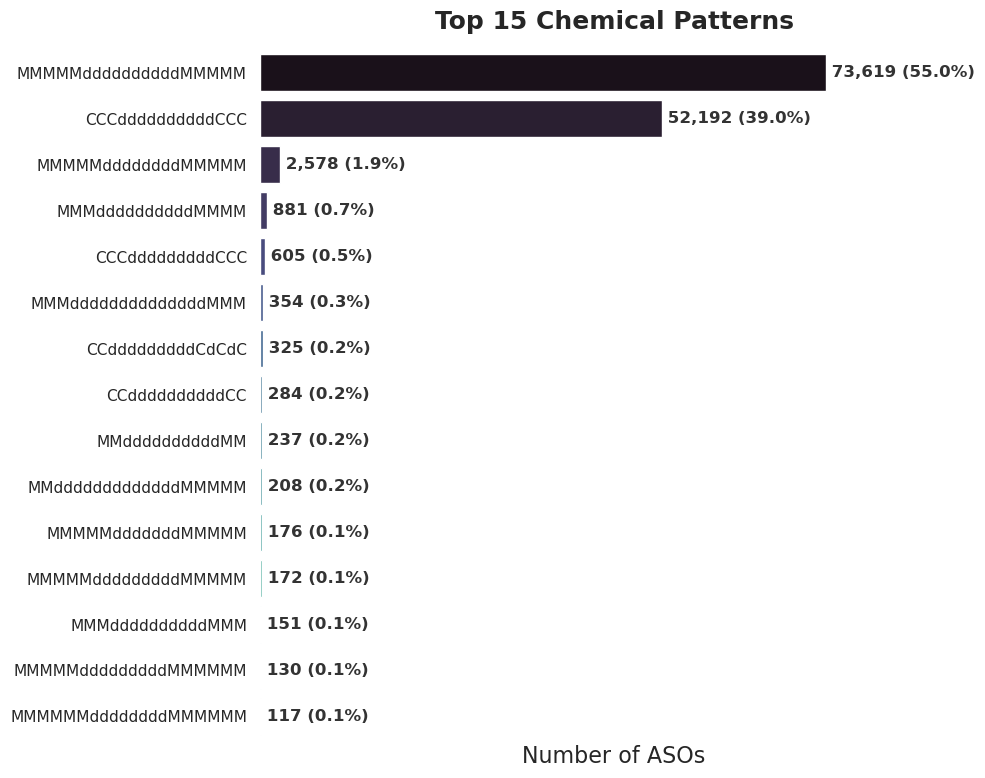

/tmp/ipykernel_97360/3525119543.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=rep_counts.index, y=rep_counts.values, palette="Blues_d")


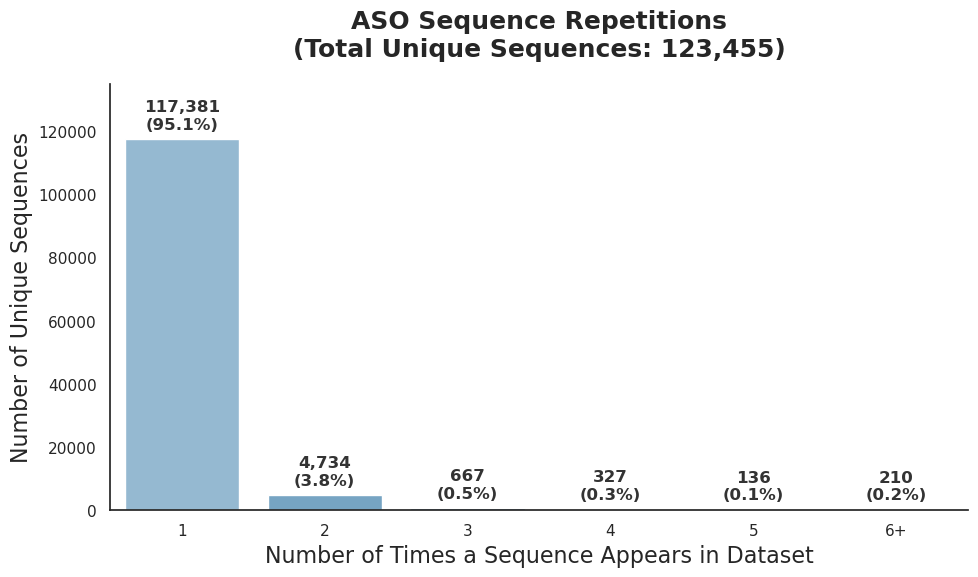

In [22]:
plot_chemical_patterns(data)
plot_sequence_repetitions(data)

In [23]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE

def split_by_cell_line(data):
    """
    Splits the data by holding out specific cell lines for the absolute test set.
    """
    # Define the cell lines to hold out completely
    test_cell_lines = ['A549', 'THP-1', 'HepaRG', 'LNCaP']

    # Create the split
    test_set = data[data[CELL_LINE].isin(test_cell_lines)].copy()
    train_set = data[~data[CELL_LINE].isin(test_cell_lines)].copy()

    # Print the summary
    print(f"--- Training Set ---")
    print(f"Total ASOs: {len(train_set)}")
    print(f"Unique Cell Lines: {train_set[CELL_LINE].nunique()}")
    print(f"Unique Genes: {train_set[CANONICAL_GENE].nunique()}\n")

    print(f"--- Absolute Test Set ---")
    print(f"Total ASOs: {len(test_set)}")
    print(f"Held-out Cell Lines: {', '.join(test_cell_lines)}")
    print(f"Unique Genes in Test: {test_set[CANONICAL_GENE].nunique()}")

    # Check for gene overlap (some genes might exist in both sets, which is fine,
    # but it's good to know exactly how many are strictly zero-shot)
    train_genes = set(train_set[CANONICAL_GENE])
    test_genes = set(test_set[CANONICAL_GENE])
    overlap = train_genes.intersection(test_genes)

    print(f"\nGenes appearing in BOTH sets: {len(overlap)}")
    print(f"Genes appearing ONLY in Test Set (Zero-Shot): {len(test_genes) - len(overlap)}")

    return train_set, test_set


# 2. Now run the Train/Test Split on the filtered data
# (Using the A549, THP-1, HepaRG, LNCaP holdout strategy we set up earlier)
train_data, test_data = split_by_cell_line(data)

--- Training Set ---
Total ASOs: 113119
Unique Cell Lines: 25
Unique Genes: 156

--- Absolute Test Set ---
Total ASOs: 20655
Held-out Cell Lines: A549, THP-1, HepaRG, LNCaP
Unique Genes in Test: 77

Genes appearing in BOTH sets: 8
Genes appearing ONLY in Test Set (Zero-Shot): 69


In [24]:
from pathlib import Path
from notebooks.consts import OLIGO_CSV_INDEXED

# 2. Dynamically determine the save paths
base_dir = Path(OLIGO_CSV_INDEXED).parent
train_path = base_dir / 'oligo_train.csv'
test_path = base_dir / 'oligo_test.csv'

# 3. Save the datasets
print(f"Saving training set to: {train_path}")
train_data.to_csv(train_path, index=False)

print(f"Saving absolute test set to: {test_path}")
test_data.to_csv(test_path, index=False)

print("Data successfully split and saved!")

Saving training set to: /home/michael/career/tauso_article/tauso_source2/notebooks/competitors/oligo_ai/oligo_train.csv
Saving absolute test set to: /home/michael/career/tauso_article/tauso_source2/notebooks/competitors/oligo_ai/oligo_test.csv
Data successfully split and saved!
